# Customer Churn Intelligence System - Modern Stack

Notebook ini meng-upgrade project ke stack yang lebih modern dan tetap realistis untuk dijalankan:

- **CatBoost** untuk churn prediction tabular
- **Sentence Transformers** untuk representasi feedback text
- **Combined modern model** yang menggabungkan tabular + sentiment + text embeddings
- **Business logic layer** untuk risk tier dan rekomendasi tindakan

Catatan:
- Untuk **tabular foundation model** seperti TabPFN, ekosistemnya masih lebih spesial untuk eksperimen dan sering butuh setup tambahan.
- Karena notebook ini ditujukan agar bisa dipakai dan dipresentasikan dengan stabil, kita pilih stack modern yang lebih production-friendly.


## Modern Stack yang Dipakai

- **CatBoost**: gradient boosting modern yang sangat kuat untuk data tabular dan kategorikal
- **Sentence Transformers**: model embedding modern untuk menangkap makna teks, bukan hanya hitung kata seperti TF-IDF
- **PCA on embeddings**: merangkum informasi embedding agar ringan dipakai model gabungan
- **CatBoost combined model**: memanfaatkan sinyal numerik, kategorikal, sentiment, dan semantic text sekaligus


In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn catboost sentence-transformers joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from catboost import CatBoostClassifier, Pool

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

RAW_DATA_PATH = 'dataset/telco_churn_with_all_feedback.csv'
PREP_DATA_PATH = 'dataset/telco_prep.csv'
OUTPUT_DIR = 'dataset/output_modern'
RANDOM_STATE = 42
TEST_SIZE = 0.2
EMBED_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
N_EMBED_COMPONENTS = 32

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Setup modern stack selesai.')


Setup modern stack selesai.


In [3]:
# 1) Load dan cleaning data
df = pd.read_csv(RAW_DATA_PATH).copy()
prep_df = pd.read_csv(PREP_DATA_PATH).copy()

for frame in [df, prep_df]:
    unnamed_cols = [c for c in frame.columns if c.lower().startswith('unnamed') or c == '']
    if unnamed_cols:
        frame.drop(columns=unnamed_cols, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['CustomerFeedback'] = df['CustomerFeedback'].fillna('')
df['ChurnLabel'] = (df['Churn'].astype(str).str.strip().str.lower() == 'yes').astype(int)

prep_df['CustomerFeedback'] = prep_df['CustomerFeedback'].fillna('')
prep_df['sentiment'] = pd.to_numeric(prep_df['sentiment'], errors='coerce').fillna(0.0)

def sentiment_bucket(score):
    if score > 0.05:
        return 'Positive'
    if score < -0.05:
        return 'Negative'
    return 'Neutral'

prep_df['sentiment_label'] = prep_df['sentiment'].apply(sentiment_bucket)
prep_df = prep_df[prep_df['CustomerFeedback'].str.strip() != ''].copy()

drop_cols = [c for c in ['customerID', 'PromptInput'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

print('Shape data utama:', df.shape)
print('Shape data sentiment:', prep_df.shape)
print('Churn rate: {:.2f}%'.format(df['ChurnLabel'].mean() * 100))
display(df.head(3))


Shape data utama: (7043, 22)
Shape data sentiment: (7032, 26)
Churn rate: 26.54%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerFeedback,ChurnLabel
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,I have been using the DSL internet service fro...,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,I have been a customer with this company for o...,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,I recently signed up for DSL internet service ...,1


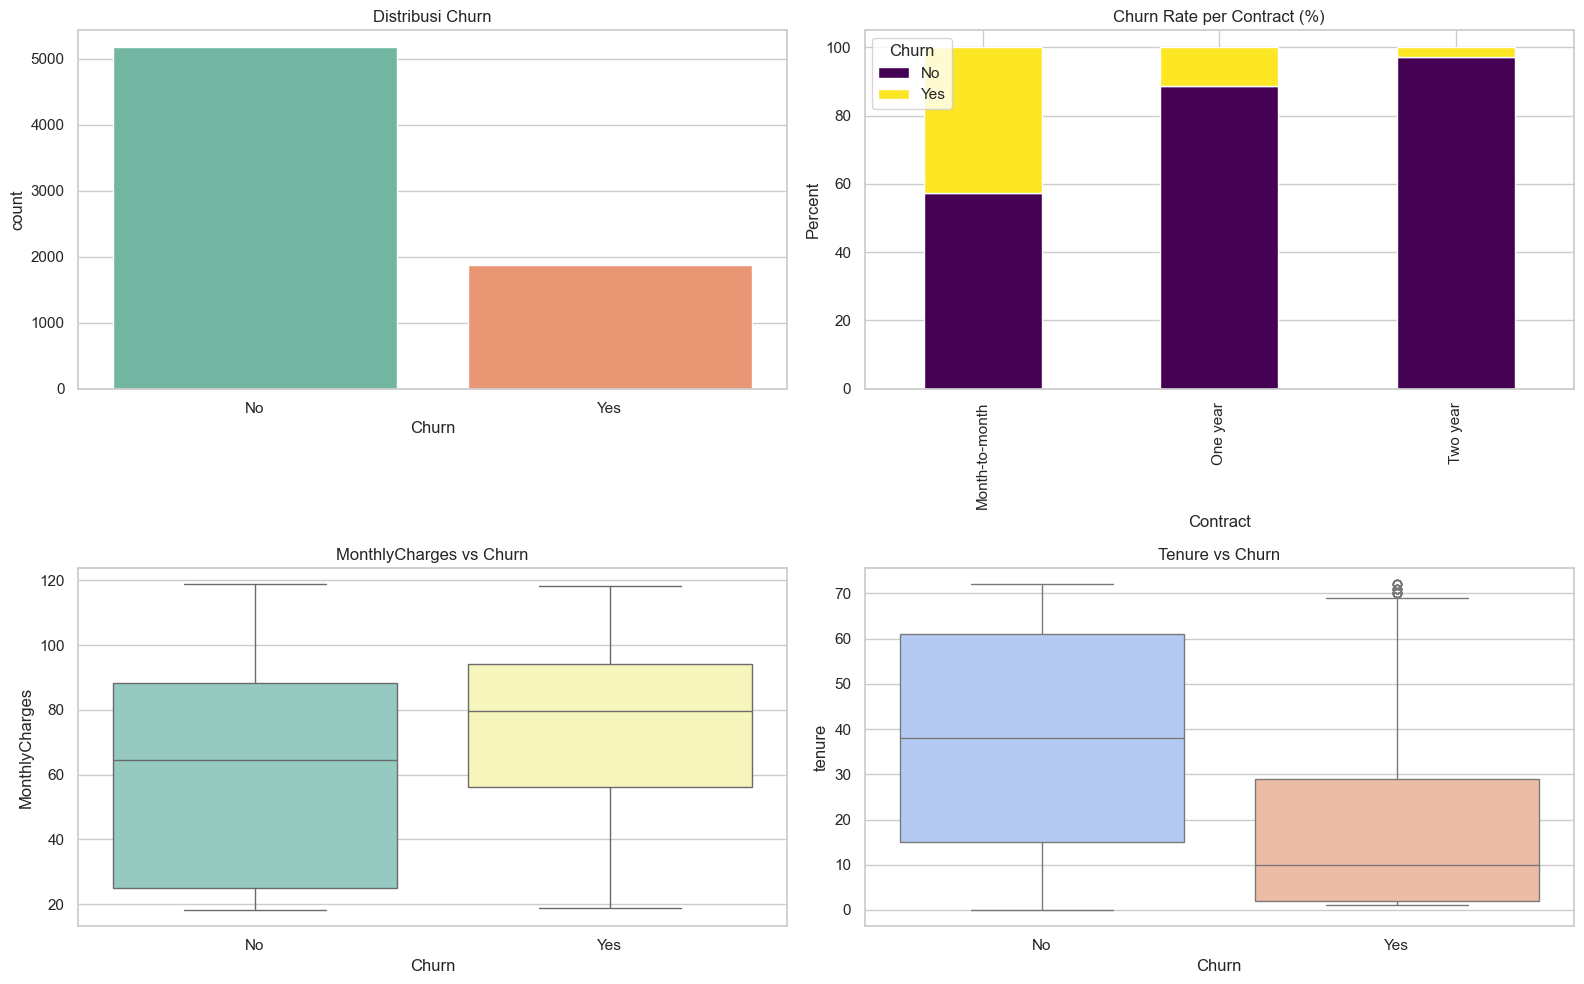

,metric,value
0,rows,7043.00
1,columns,22.00
2,churn_rate_pct,26.54
3,avg_monthly_charge,64.76
4,avg_tenure,32.37


In [4]:
# 2) EDA ringkas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribusi Churn')

pd.crosstab(df['Contract'], df['Churn'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, ax=axes[0, 1], colormap='viridis'
)
axes[0, 1].set_title('Churn Rate per Contract (%)')
axes[0, 1].set_ylabel('Percent')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('MonthlyCharges vs Churn')

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Tenure vs Churn')

plt.tight_layout()
plt.show()

eda_summary = pd.DataFrame({
    'metric': ['rows', 'columns', 'churn_rate_pct', 'avg_monthly_charge', 'avg_tenure'],
    'value': [len(df), df.shape[1], round(df['ChurnLabel'].mean() * 100, 2), round(df['MonthlyCharges'].mean(), 2), round(df['tenure'].mean(), 2)]
})
display(eda_summary)


## Modern NLP Layer: Sentence Transformers

Kita tidak lagi memakai TF-IDF. Di versi modern ini, feedback text diubah menjadi **semantic embedding** sehingga model bisa menangkap makna yang lebih kaya.


In [5]:
# 3) Build modern text features dengan Sentence Transformers
embedder = SentenceTransformer(EMBED_MODEL_NAME)

X_text = prep_df['CustomerFeedback'].tolist()
y_text = prep_df['sentiment_label'].copy()

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text, y_text, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_text
)

text_train_embeddings = embedder.encode(X_text_train, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
text_test_embeddings = embedder.encode(X_text_test, batch_size=64, show_progress_bar=True, normalize_embeddings=True)

text_clf = LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE)
text_clf.fit(text_train_embeddings, y_text_train)
text_pred = text_clf.predict(text_test_embeddings)

print('Classification report - modern sentiment model:')
print(classification_report(y_text_test, text_pred))

all_feedback_embeddings = embedder.encode(df['CustomerFeedback'].tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)
all_sentiment_pred = text_clf.predict(all_feedback_embeddings)
all_sentiment_proba = text_clf.predict_proba(all_feedback_embeddings)

df['predicted_sentiment_label'] = all_sentiment_pred
df['predicted_sentiment_score'] = df['predicted_sentiment_label'].map({'Negative': -1, 'Neutral': 0, 'Positive': 1})
df['sentiment_confidence'] = all_sentiment_proba.max(axis=1)
df['feedback_length'] = df['CustomerFeedback'].str.len()
df['feedback_word_count'] = df['CustomerFeedback'].str.split().str.len()

for idx, cls in enumerate(text_clf.classes_):
    df[f'sent_prob_{cls.lower()}'] = all_sentiment_proba[:, idx]

display(df[['CustomerFeedback', 'predicted_sentiment_label', 'sentiment_confidence']].head(5))


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9025.47it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 22/22 [00:01<00:00, 15.31it/s]


Classification report - modern sentiment model:
              precision    recall  f1-score   support

    Negative       0.57      0.76      0.65        76
     Neutral       0.23      0.49      0.31       131
    Positive       0.96      0.82      0.88      1200

    accuracy                           0.79      1407
   macro avg       0.59      0.69      0.62      1407
weighted avg       0.87      0.79      0.82      1407



Batches: 100%|██████████| 111/111 [00:07<00:00, 15.37it/s]


,CustomerFeedback,predicted_sentiment_label,sentiment_confidence
0,I have been using the DSL internet service fro...,Positive,0.836119
1,I have been a customer with this company for o...,Positive,0.744478
2,I recently signed up for DSL internet service ...,Negative,0.780664
3,I have been a loyal customer with this company...,Positive,0.871892
4,I recently switched to this fiber optic intern...,Neutral,0.679932


## Modern Tabular Model: CatBoost

Untuk data tabular modern, kita upgrade dari Logistic Regression / Random Forest ke **CatBoost**, yang memang sangat kuat untuk numerik + kategorikal.


In [6]:
# 4) CatBoost untuk churn prediction berbasis tabular
tabular_cols = [c for c in df.columns if c not in ['Churn', 'ChurnLabel', 'CustomerFeedback', 'predicted_sentiment_label', 'predicted_sentiment_score', 'sentiment_confidence', 'feedback_length', 'feedback_word_count', 'sent_prob_negative', 'sent_prob_neutral', 'sent_prob_positive']]
X_tab = df[tabular_cols].copy()
y = df['ChurnLabel'].copy()

cat_cols_tab = X_tab.select_dtypes(exclude=['number']).columns.tolist()
for col in cat_cols_tab:
    X_tab[col] = X_tab[col].fillna('missing').astype(str)

X_tab_train, X_tab_test, y_tab_train, y_tab_test = train_test_split(
    X_tab, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

tabular_model = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

tab_pool_train = Pool(X_tab_train, y_tab_train, cat_features=cat_cols_tab)
tab_pool_test = Pool(X_tab_test, y_tab_test, cat_features=cat_cols_tab)

tabular_model.fit(tab_pool_train, eval_set=tab_pool_test, use_best_model=True)
tab_prob = tabular_model.predict_proba(tab_pool_test)[:, 1]
tab_pred = (tab_prob >= 0.5).astype(int)

tabular_metrics = pd.DataFrame([{
    'model': 'CatBoost Tabular',
    'precision': precision_score(y_tab_test, tab_pred),
    'recall': recall_score(y_tab_test, tab_pred),
    'f1': f1_score(y_tab_test, tab_pred),
    'roc_auc': roc_auc_score(y_tab_test, tab_prob)
}])

display(tabular_metrics)
print('Classification report - CatBoost tabular:')
print(classification_report(y_tab_test, tab_pred, digits=3))


,model,precision,recall,f1,roc_auc
0,CatBoost Tabular,0.523973,0.818182,0.638831,0.853823


Classification report - CatBoost tabular:
              precision    recall  f1-score   support

           0      0.918     0.731     0.814      1035
           1      0.524     0.818     0.639       374

    accuracy                          0.754      1409
   macro avg      0.721     0.775     0.726      1409
weighted avg      0.813     0.754     0.767      1409



## Combined Modern Model

Di tahap ini kita gabungkan:

- fitur tabular asli
- hasil sentiment modern
- fitur embedding yang sudah diringkas dengan PCA

Ini adalah versi modern dari konsep `tabular + NLP fusion`.


,model,precision,recall,f1,roc_auc
1,CatBoost Combined Modern,0.994595,0.983957,0.989247,0.999881
0,CatBoost Tabular,0.523973,0.818182,0.638831,0.853823


Classification report - combined modern model:
              precision    recall  f1-score   support

           0      0.994     0.998     0.996      1035
           1      0.995     0.984     0.989       374

    accuracy                          0.994      1409
   macro avg      0.994     0.991     0.993      1409
weighted avg      0.994     0.994     0.994      1409



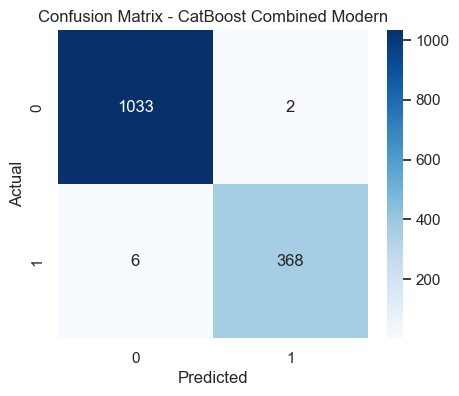

In [7]:
# 5) Ringkas semantic embedding dengan PCA agar efisien dipakai model gabungan
train_idx, test_idx = train_test_split(
    df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df['ChurnLabel']
)

pca = PCA(n_components=N_EMBED_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(all_feedback_embeddings[train_idx])
embedding_pca = pca.transform(all_feedback_embeddings)

embedding_cols = [f'emb_pc_{i+1}' for i in range(N_EMBED_COMPONENTS)]
embedding_df = pd.DataFrame(embedding_pca, columns=embedding_cols, index=df.index)

combined_df = pd.concat([
    df.drop(columns=['Churn', 'ChurnLabel', 'CustomerFeedback']).copy(),
    embedding_df
], axis=1)

combined_cat_cols = combined_df.select_dtypes(exclude=['number']).columns.tolist()
for col in combined_cat_cols:
    combined_df[col] = combined_df[col].fillna('missing').astype(str)

X_combined_train = combined_df.loc[train_idx].copy()
X_combined_test = combined_df.loc[test_idx].copy()
y_combined_train = df.loc[train_idx, 'ChurnLabel']
y_combined_test = df.loc[test_idx, 'ChurnLabel']

combined_model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.04,
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

comb_pool_train = Pool(X_combined_train, y_combined_train, cat_features=combined_cat_cols)
comb_pool_test = Pool(X_combined_test, y_combined_test, cat_features=combined_cat_cols)

combined_model.fit(comb_pool_train, eval_set=comb_pool_test, use_best_model=True)
combined_prob = combined_model.predict_proba(comb_pool_test)[:, 1]
combined_pred = (combined_prob >= 0.5).astype(int)

combined_metrics = pd.DataFrame([{
    'model': 'CatBoost Combined Modern',
    'precision': precision_score(y_combined_test, combined_pred),
    'recall': recall_score(y_combined_test, combined_pred),
    'f1': f1_score(y_combined_test, combined_pred),
    'roc_auc': roc_auc_score(y_combined_test, combined_prob)
}])

comparison_df = pd.concat([tabular_metrics, combined_metrics], ignore_index=True).sort_values('roc_auc', ascending=False)
display(comparison_df)

print('Classification report - combined modern model:')
print(classification_report(y_combined_test, combined_pred, digits=3))

cm = confusion_matrix(y_combined_test, combined_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CatBoost Combined Modern')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [8]:
# 6) Scoring semua customer + business logic modern
df['churn_probability_modern'] = combined_model.predict_proba(Pool(combined_df, cat_features=combined_cat_cols))[:, 1]
df['churn_prediction_modern'] = np.where(df['churn_probability_modern'] >= 0.5, 'Yes', 'No')

def risk_tier(prob):
    if prob >= 0.80:
        return 'High'
    if prob >= 0.50:
        return 'Medium'
    return 'Low'

def build_reason(row):
    reasons = []
    if row.get('tenure', 999) <= 12:
        reasons.append('tenure pendek')
    if row.get('MonthlyCharges', 0) >= 70:
        reasons.append('monthly charge tinggi')
    if str(row.get('Contract', '')).lower() == 'month-to-month':
        reasons.append('kontrak bulanan')
    if row.get('predicted_sentiment_label') == 'Negative':
        reasons.append('feedback negatif')
    if row.get('sentiment_confidence', 0) >= 0.80:
        reasons.append('indikasi sentiment sangat kuat')
    if 'electronic check' in str(row.get('PaymentMethod', '')).lower():
        reasons.append('electronic check')
    return ', '.join(reasons) if reasons else 'tidak ada sinyal risiko dominan'

def build_recommendation(row):
    prob = row['churn_probability_modern']
    sentiment = row['predicted_sentiment_label']
    contract = str(row.get('Contract', '')).lower()

    if prob >= 0.80:
        if sentiment == 'Negative':
            return 'High risk -> retention call prioritas, service recovery, diskon personal, dan follow-up manajer CS'
        return 'High risk -> retention call, kontrak tahunan diskon, dan loyalty bundle'
    if prob >= 0.50:
        if contract == 'month-to-month':
            return 'Medium risk -> dorong migrasi ke kontrak 1 tahun + promo bundle'
        return 'Medium risk -> promo personal dan kampanye CRM tersegmentasi'
    return 'Low risk -> pertahankan engagement, loyalty program, dan monitoring rutin'

df['risk_tier_modern'] = df['churn_probability_modern'].apply(risk_tier)
df['risk_reason_modern'] = df.apply(build_reason, axis=1)
df['recommendation_modern'] = df.apply(build_recommendation, axis=1)

priority_cols = [
    'gender', 'SeniorCitizen', 'tenure', 'Contract', 'PaymentMethod', 'MonthlyCharges',
    'predicted_sentiment_label', 'sentiment_confidence', 'churn_probability_modern',
    'risk_tier_modern', 'risk_reason_modern', 'recommendation_modern'
]
priority_cols = [c for c in priority_cols if c in df.columns]

display(df.sort_values('churn_probability_modern', ascending=False)[priority_cols].head(15))
display(df['risk_tier_modern'].value_counts(normalize=True).round(3).to_frame('proportion'))


,gender,SeniorCitizen,tenure,Contract,PaymentMethod,MonthlyCharges,predicted_sentiment_label,sentiment_confidence,churn_probability_modern,risk_tier_modern,risk_reason_modern,recommendation_modern
3469,Female,1,3,Month-to-month,Electronic check,79.40,Neutral,0.531179,0.999997,High,"tenure pendek, monthly charge tinggi, kontrak ...","High risk -> retention call, kontrak tahunan d..."
1037,Female,0,2,Month-to-month,Mailed check,79.65,Negative,0.533158,0.999995,High,"tenure pendek, monthly charge tinggi, kontrak ...","High risk -> retention call prioritas, service..."
4519,Male,1,1,Month-to-month,Electronic check,93.55,Negative,0.478780,0.999995,High,"tenure pendek, monthly charge tinggi, kontrak ...","High risk -> retention call prioritas, service..."
4401,Female,0,19,Month-to-month,Electronic check,73.20,Neutral,0.545947,0.999995,High,"monthly charge tinggi, kontrak bulanan, electr...","High risk -> retention call, kontrak tahunan d..."
4207,Female,0,46,Month-to-month,Bank transfer (automatic),96.05,Neutral,0.539699,0.999995,High,"monthly charge tinggi, kontrak bulanan","High risk -> retention call, kontrak tahunan d..."
6288,Male,0,7,Month-to-month,Electronic check,94.25,Neutral,0.522935,0.999995,High,"tenure pendek, monthly charge tinggi, kontrak ...","High risk -> retention call, kontrak tahunan d..."
1043,Male,1,19,Month-to-month,Electronic check,90.60,Neutral,0.380731,0.999994,High,"monthly charge tinggi, kontrak bulanan, electr...","High risk -> retention call, kontrak tahunan d..."
6773,Male,0,11,Month-to-month,Electronic check,73.50,Neutral,0.506429,0.999994,High,"tenure pendek, monthly charge tinggi, kontrak ...","High risk -> retention call, kontrak tahunan d..."
6896,Female,0,1,Month-to-month,Electronic check,74.90,Neutral,0.575173,0.999994,High,"tenure pendek, monthly charge tinggi, kontrak ...","High risk -> retention call, kontrak tahunan d..."
2654,Female,0,7,Month-to-month,Electronic check,86.50,Neutral,0.489205,0.999994,High,"tenure pendek, monthly charge tinggi, kontrak ...","High risk -> retention call, kontrak tahunan d..."


,proportion
risk_tier_modern,
Low,0.735
High,0.264
Medium,0.001


,feature,importance
24,sent_prob_negative,11.419812
7,InternetService,9.104876
30,emb_pc_4,7.500756
27,emb_pc_1,6.159490
26,sent_prob_positive,5.649942
38,emb_pc_12,4.350637
28,emb_pc_2,4.072341
36,emb_pc_10,3.903226
19,predicted_sentiment_label,3.644115
29,emb_pc_3,3.490793


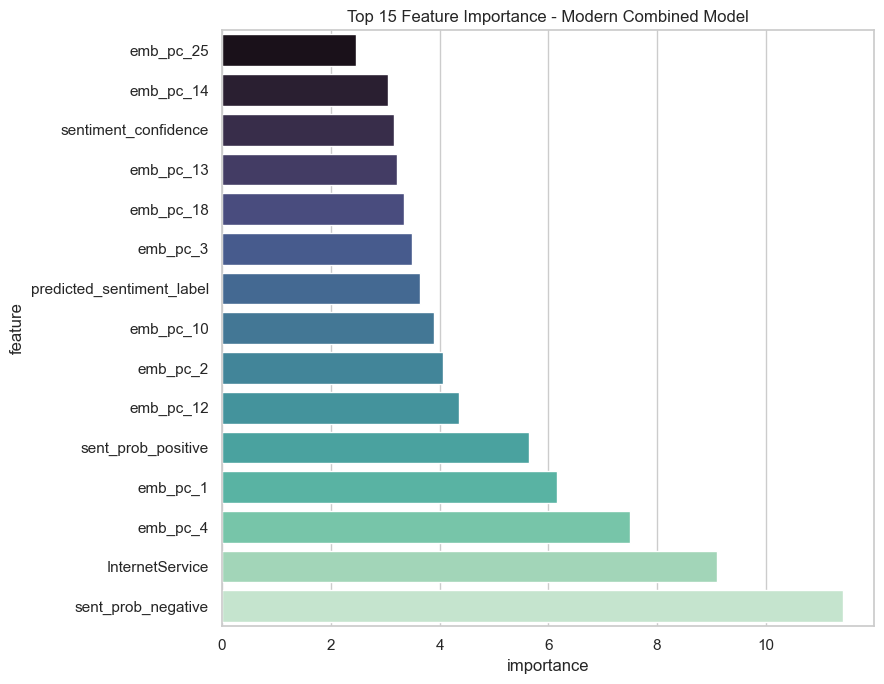

In [9]:
# 7) Feature importance modern model
importance_df = pd.DataFrame({
    'feature': combined_df.columns,
    'importance': combined_model.get_feature_importance()
}).sort_values('importance', ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(9, 7))
plot_df = importance_df.head(15).sort_values('importance')
sns.barplot(data=plot_df, x='importance', y='feature', palette='mako')
plt.title('Top 15 Feature Importance - Modern Combined Model')
plt.tight_layout()
plt.show()


In [10]:
# 8) Simpan artefak modern
tabular_model.save_model(os.path.join(OUTPUT_DIR, 'catboost_tabular_model.cbm'))
combined_model.save_model(os.path.join(OUTPUT_DIR, 'catboost_combined_modern_model.cbm'))
joblib.dump(text_clf, os.path.join(OUTPUT_DIR, 'modern_sentiment_classifier.joblib'))
joblib.dump(embedder, os.path.join(OUTPUT_DIR, 'sentence_transformer_embedder.joblib'))
joblib.dump(pca, os.path.join(OUTPUT_DIR, 'embedding_pca.joblib'))

output_cols = [
    c for c in [
        'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
        'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
        'predicted_sentiment_label', 'predicted_sentiment_score', 'sentiment_confidence',
        'churn_probability_modern', 'churn_prediction_modern', 'risk_tier_modern',
        'risk_reason_modern', 'recommendation_modern'
    ] if c in df.columns
]
df[output_cols].to_csv(os.path.join(OUTPUT_DIR, 'modern_customer_churn_intelligence_output.csv'), index=False)

metadata = {
    'created_from_notebook': '3_modern_churn_intelligence.ipynb',
    'raw_data_path': RAW_DATA_PATH,
    'prep_data_path': PREP_DATA_PATH,
    'embedding_model_name': EMBED_MODEL_NAME,
    'embedding_components': N_EMBED_COMPONENTS,
    'tabular_metrics': tabular_metrics.to_dict(orient='records'),
    'combined_metrics': combined_metrics.to_dict(orient='records'),
    'risk_thresholds': {'high': 0.8, 'medium': 0.5},
    'api_example': {
        'request': {
            'tenure': 5,
            'monthly_charges': 80,
            'feedback': 'service is expensive and slow'
        },
        'response_fields': ['churn_probability_modern', 'predicted_sentiment_label', 'recommendation_modern']
    }
}

with open(os.path.join(OUTPUT_DIR, 'modern_model_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Artefak modern tersimpan di:', OUTPUT_DIR)


Artefak modern tersimpan di: dataset/output_modern


## Ringkasan Upgrade

Upgrade utama di notebook ini:

- `TF-IDF` diganti menjadi **Sentence Transformers embeddings**
- `Logistic Regression / Random Forest` untuk tabular diganti menjadi **CatBoost**
- model gabungan sekarang memakai **semantic text features**, bukan hanya sentiment score sederhana
- output tetap mempertahankan **probability + sentiment + recommendation**, jadi tetap siap diarahkan ke API atau dashboard

Kalau nanti ingin naik satu level lagi, langkah berikutnya adalah membungkus artefak ini menjadi service `FastAPI` atau `Streamlit` app.
